In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data: https://github.com/atilsamancioglu/DeepLearningBootcamp/blob/main/09-iris.csv

df = pd.read_csv('09-iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

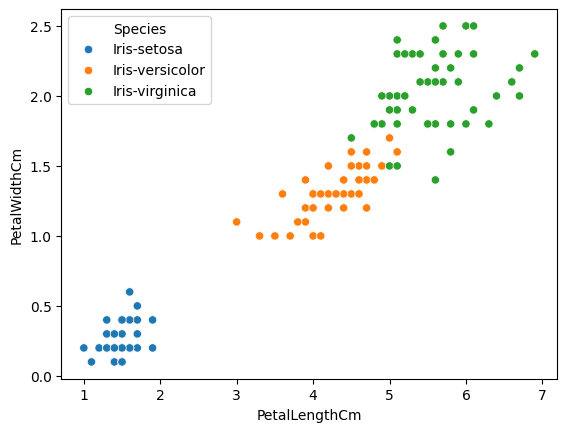

In [5]:
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species")
plt.show()

In [6]:
df = df.drop("Id", axis=1)

In [7]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].values
y = df["Species"].values

In [8]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [9]:
# label encoding
# (setosa=0, versicolor=1, virginica=2)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# stratiy=y -> y'yi eşit bir şekilde ayırır
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [12]:
len(X_train), len(X_test), len(y_train), len(y_test)

(120, 30, 120, 30)

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# multi class classification' da y tipi long olmalı, loss fonk cross entropy nedeniyle
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [14]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([120, 4]) torch.Size([30, 4])
torch.Size([120]) torch.Size([30])


In [15]:
class IrisClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(4, 16) # 4 features
    self.layer_2 = nn.Linear(16, 16)
    self.layer_3 = nn.Linear(16, 3) # 3 classes

    self.relu = nn.ReLU() # Bu arada, modelimizin Relu'ya bile ihtiyacı olmayabilir, biraz doğrusal gibi görünüyor yine de ekleyelim

  def forward(self, x):
    return self.layer_1(self.relu(self.layer_2(self.relu(self.layer_3(x)))))

In [16]:
# Bu sınıfı bu şekilde de tanımlayabiliriz.
class IrisClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer_stack = nn.Sequential(
        nn.Linear(4, 16),    # input: 4 features
        nn.ReLU(),           # aktivaston fonksiyonu

        nn.Linear(16, 16),   # hidden layer
        nn.ReLU(),

        nn.Linear(16, 3)     # output: 3 sınıf
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

In [17]:
# Model
model = IrisClassifier()
model = torch.compile(model)

# Loss Function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [18]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [19]:
# Çok sınıflı (multi-class) bir PyTorch modelinde tahmin olasılıkları biraz farklı görünebilir

In [20]:
# Henüz eğitim yapmadan veri üzerinde tek bir forward pass (ileri besleme) gerçekleştiriyoruz
model(X_test)[:5] # çıktılar logits

tensor([[ 0.3490,  0.0207, -0.1629],
        [ 0.3457,  0.0818, -0.1521],
        [ 0.2976,  0.0852, -0.1490],
        [ 0.3075,  0.0797, -0.1504],
        [ 0.3429,  0.0207, -0.1654]], grad_fn=<SliceBackward0>)

In [21]:
# 3 değer elde ediyoruz çünkü 3 sınıfımız var.
# Her bir sınıf için olasılık (probability) değerleri elde ediyoruz.

# Bu yüzden en yüksek olasılığa sahip olanı seçip onu tahmin edilen sınıf olarak atamamız gerekiyor.
# İkili sınıflandırmada (binary classification) buna gerek yoktu çünkü sadece 2 sınıf vardı.
# Eğer değer 0.5'ten büyükse bunu 1 olarak kabul ediyorduk.

In [22]:
y_logits = model(X_test)

# Logit değerlerine softmax uygulayarak, 1. boyut (dim=1) boyunca olasılıkları elde ediyoruz
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 0.3490,  0.0207, -0.1629],
        [ 0.3457,  0.0818, -0.1521],
        [ 0.2976,  0.0852, -0.1490],
        [ 0.3075,  0.0797, -0.1504],
        [ 0.3429,  0.0207, -0.1654]], grad_fn=<SliceBackward0>)
tensor([[0.4311, 0.3105, 0.2584],
        [0.4209, 0.3233, 0.2558],
        [0.4084, 0.3303, 0.2613],
        [0.4117, 0.3278, 0.2605],
        [0.4299, 0.3115, 0.2586]], grad_fn=<SliceBackward0>)


In [23]:
# Model henüz eğitilmediği için her sınıf için tahminler birbirine oldukça yakın görünüyor
# Ancak bu değerlerin toplamı 1'dir (yani %100 eder)

# Burada argmax almak istersek bu oldukça kolaydır
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.4311, 0.3105, 0.2584], grad_fn=<SelectBackward0>)
tensor(0)


In [24]:
epochs = 200

# loss (kayıp) ve accuracy (doğruluk) değerlerini çizdirelim
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
  # Eğitim

  model.train()
  logits = model(X_train)
  loss = loss_fn(logits, y_train)

  # Tahminleri şu şekilde de elde edebiliriz:
  # pred = torch.argmax(logits, dim=1)
  # (Bu yöntemle veya aşağıdaki satırla aynı sonucu alırız.
  # Çünkü cross entropy loss zaten softmax hesaplamasını içinde barındırır.)

  pred = torch.softmax(logits, dim=1).argmax(dim=1)
  # logits -> olasılık değerleri (softmax) -> sınıf etiketleri (argmax) dönüşümü

  acc = calculate_accuracy(y_train, pred)

  # Gradient sıfırla: Önceki epoch’tan kalan gradientleri temizler.
  optimizer.zero_grad()

  # Backpropagation (geri yayılım): Hatanın modele nasıl dağıldığını hesaplar.
  loss.backward()

  # Ağırlıkları güncelle: Model öğrenir
  optimizer.step()

  train_losses.append(loss.item())
  train_accuracies.append(acc)

  # Test
  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test)
    test_loss = loss_fn(test_logits, y_test)
    test_pred = torch.argmax(test_logits, dim=1)
    test_acc = calculate_accuracy(y_test, test_pred)

    test_accuracies.append(test_acc)
    test_losses.append(test_loss.item())

  if epoch % 20 == 0:
    print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.1030 | Acc: 33.33% | Test Loss: 1.0554 | Test Acc: 36.67%
Epoch 20 | Loss: 0.4508 | Acc: 74.17% | Test Loss: 0.4294 | Test Acc: 80.00%
Epoch 40 | Loss: 0.1107 | Acc: 98.33% | Test Loss: 0.1173 | Test Acc: 100.00%
Epoch 60 | Loss: 0.0664 | Acc: 98.33% | Test Loss: 0.0609 | Test Acc: 100.00%
Epoch 80 | Loss: 0.0602 | Acc: 99.17% | Test Loss: 0.0505 | Test Acc: 100.00%
Epoch 100 | Loss: 0.0568 | Acc: 98.33% | Test Loss: 0.0480 | Test Acc: 100.00%
Epoch 120 | Loss: 0.0542 | Acc: 98.33% | Test Loss: 0.0465 | Test Acc: 100.00%
Epoch 140 | Loss: 0.0519 | Acc: 98.33% | Test Loss: 0.0458 | Test Acc: 100.00%
Epoch 160 | Loss: 0.0498 | Acc: 98.33% | Test Loss: 0.0454 | Test Acc: 100.00%
Epoch 180 | Loss: 0.0481 | Acc: 98.33% | Test Loss: 0.0454 | Test Acc: 100.00%


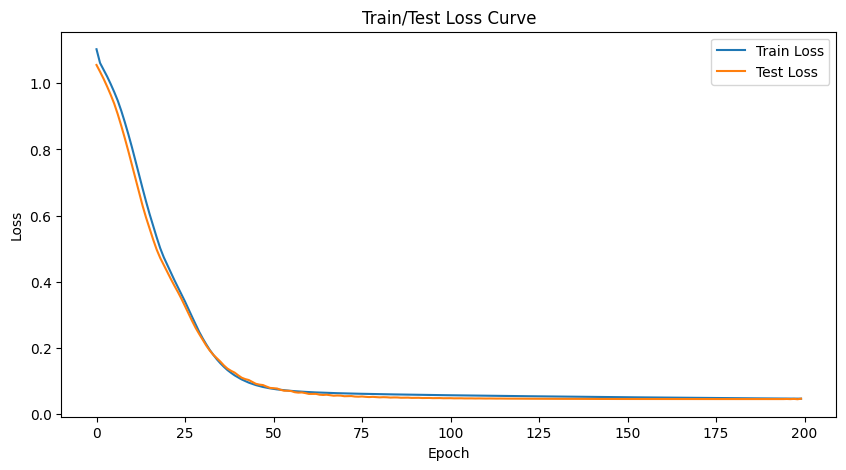

In [25]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()
plt.show()

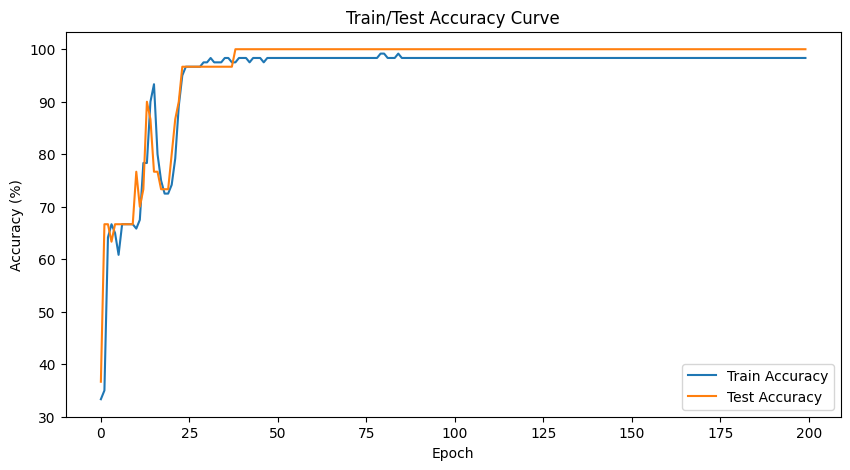

In [26]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()
plt.show()

In [27]:
# Diyelim ki yeni bir çiçek örneği aldık ve hangi sınıfa ait olduğunu bulmaya çalışıyoruz.

new_sample = np.array([[5.1, 3.5, 1.4, 0.2]]) # sıralı bir şekilde 4 özelliğimiz

In [28]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [29]:
new_sample_tensor.shape

torch.Size([1, 4])

In [30]:
model.eval()
with torch.inference_mode():
  logits = model(new_sample_tensor)
  probs = torch.softmax(logits, dim=1)
  predicted_class = torch.argmax(probs, dim=1).item()

In [31]:
predicted_label = le.inverse_transform([predicted_class])[0]

In [32]:
print("Predicted Class Index:", predicted_class)
print("Predicted Species:", predicted_label)

Predicted Class Index: 0
Predicted Species: Iris-setosa


In [33]:
# torchmetrics
# • Accuracy • Precision • Recall • F1-score • Confusion Matrix • ROC-AUC • Multi-class, multi-label, binary etc. • GPU comptabile

In [34]:
# !pip install torchmetrics
from torchmetrics.classification import MulticlassAccuracy

In [35]:
accuracy = MulticlassAccuracy(num_classes=3)

In [36]:
epochs = 200
model2 = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)

for epoch in range(epochs):

  model2.train()
  logits = model2(X_train)
  loss = loss_fn(logits, y_train)

  pred = torch.softmax(logits, dim=1).argmax(dim=1)
  acc = accuracy(pred, y_train).item() * 100

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model2.eval()
  with torch.inference_mode():
    test_logits = model2(X_test)
    test_loss = loss_fn(test_logits, y_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_acc = accuracy(test_pred, y_test).item() * 100

  if epoch % 20 == 0:
    print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.1455 | Acc: 33.33% | Test Loss: 1.0868 | Test Acc: 33.33%
Epoch 20 | Loss: 0.5089 | Acc: 80.83% | Test Loss: 0.4879 | Test Acc: 83.33%
Epoch 40 | Loss: 0.1521 | Acc: 97.50% | Test Loss: 0.1551 | Test Acc: 100.00%
Epoch 60 | Loss: 0.0680 | Acc: 97.50% | Test Loss: 0.0591 | Test Acc: 100.00%
Epoch 80 | Loss: 0.0578 | Acc: 97.50% | Test Loss: 0.0438 | Test Acc: 100.00%
Epoch 100 | Loss: 0.0542 | Acc: 98.33% | Test Loss: 0.0423 | Test Acc: 100.00%
Epoch 120 | Loss: 0.0518 | Acc: 98.33% | Test Loss: 0.0430 | Test Acc: 100.00%
Epoch 140 | Loss: 0.0499 | Acc: 98.33% | Test Loss: 0.0435 | Test Acc: 100.00%
Epoch 160 | Loss: 0.0497 | Acc: 98.33% | Test Loss: 0.0345 | Test Acc: 100.00%
Epoch 180 | Loss: 0.0473 | Acc: 98.33% | Test Loss: 0.0458 | Test Acc: 100.00%


In [37]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [38]:
cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)

In [39]:
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

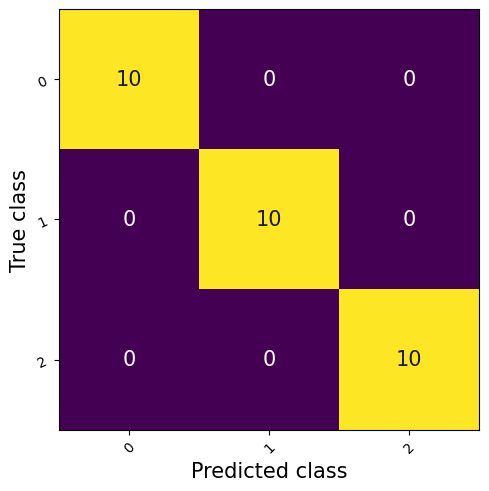

In [40]:
from torchmetrics.utilities.plot import plot_confusion_matrix
plot_confusion_matrix(matrix)

In [41]:
# model save - load - deploy

In [42]:
from pathlib import Path

In [43]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "iris_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model2.state_dict(), f=MODEL_SAVE_PATH)

In [45]:
model2.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.1602, -0.2708,  0.0381, -0.3744],
                      [-0.1406, -0.3752, -0.2845, -0.1883],
                      [-0.4806, -0.0386, -0.3117, -0.4376],
                      [ 0.8193,  0.5693, -0.4929, -0.3141],
                      [ 0.6886,  0.1544,  0.3698, -0.2526],
                      [ 0.5745,  0.5659, -0.1304, -0.9195],
                      [ 0.4152, -0.5987,  0.5322,  0.1645],
                      [ 0.1756, -0.3938,  0.8121,  0.8984],
                      [-0.2403,  0.3436, -0.0372, -0.0725],
                      [-0.1341, -0.0204,  0.3934,  0.7704],
                      [-0.4783, -0.0521, -0.4322, -0.0019],
                      [ 0.4545,  0.1433,  0.1350,  0.5718],
                      [-0.0429, -0.0155, -0.0044, -0.2497],
                      [-0.1401, -0.0555,  0.7630,  0.6131],
                      [-0.3086,  0.0445, -0.2316, -0.3442],
                      [-0.4509,  0.3367,  0.4642, -0.46

In [47]:
loaded_model = IrisClassifier()

In [48]:
type(torch.load(MODEL_SAVE_PATH))

collections.OrderedDict

In [49]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [50]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
new_sample_tensor = torch.tensor(new_sample, dtype = torch.float32)
loaded_model.eval()
with torch.inference_mode():
    logits = loaded_model(new_sample_tensor)
    probs = torch.softmax(logits, dim = 1)
    predicted_class = torch.argmax(probs, dim=1).item()
le.inverse_transform([predicted_class])[0]

'Iris-setosa'

In [ ]:
# Claude' nin notebook incelemsinden sonra oluşturduğu özet:

# 🌸 Çok Sınıflı Sınıflandırma (Multi-Class Classification) — Kapsamlı Özet

> **Kullanılan Araçlar:** PyTorch · Scikit-learn · torchmetrics · Iris Veri Seti

---

## 📌 1. Problem Nedir?

Bu notebook, **çok sınıflı sınıflandırma** (multi-class classification) problemini ele almaktadır. Hedef, bir çiçeğin ölçümlerine bakarak onun hangi türe ait olduğunu tahmin etmektir.

**Iris Veri Seti**, makine öğrenmesinin klasikleşmiş veri setlerinden biridir:

| Özellik | Açıklama |
|---|---|
| `SepalLengthCm` | Çanak yaprak uzunluğu |
| `SepalWidthCm` | Çanak yaprak genişliği |
| `PetalLengthCm` | Taç yaprak uzunluğu |
| `PetalWidthCm` | Taç yaprak genişliği |
| `Species` | Tür — **Setosa**, **Versicolor**, **Virginica** |

> **İkili sınıflandırmadan (binary) farkı:** İkili sınıflandırmada yalnızca 2 sınıf vardır ve çıkış tek bir olasılık değeridir (sigmoid). Çok sınıflı sınıflandırmada ise her sınıf için ayrı bir olasılık üretilir ve bunların toplamı 1'e eşit olur.

---

## 🔍 2. Veri Keşfi ve Ön İşleme

### 2.1 Veri Yükleme ve İnceleme

```python
df = pd.read_csv('09-iris.csv')
df.info()
df["Species"].unique()
```

Veri setinde 150 satır ve 6 sütun bulunmaktadır. `Id` sütunu anlamsız olduğu için düşürülmüştür:

```python
df = df.drop("Id", axis=1)
```

### 2.2 Görselleştirme

```python
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species")
```

Taç yaprak (petal) ölçümleri, türleri birbirinden ayırmada oldukça başarılıdır. Setosa türü diğerlerinden net biçimde ayrışmaktadır.

### 2.3 Label Encoding — Etiket Kodlama

Model sayısal verilerle çalışır; bu nedenle metin etiketleri sayılara dönüştürülmüştür:

```python
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
# setosa → 0, versicolor → 1, virginica → 2
```

> 💡 `le.inverse_transform()` ile sayısal tahminleri tekrar orijinal isimlere çevirebilirsin.

### 2.4 Train/Test Ayrımı

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

- **`test_size=0.2`:** Verinin %20'si teste ayrılır.
- **`stratify=y`:** Her sınıfın eğitim ve test setlerinde eşit oranda temsil edilmesini sağlar. Bu parametre olmadan bazı sınıflar az temsil edilebilir.

### 2.5 PyTorch Tensor Dönüşümü

```python
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)   # ⚠️ Dikkat: long (int64)!
```

> ⚠️ **Kritik Nokta:** Multi-class sınıflandırmada `y` değerleri `torch.long` (int64) tipinde olmalıdır. `CrossEntropyLoss` bu tipi bekler. Yanlış tip verilirse hata alırsın.

---

## 🧠 3. Model Mimarisi

```python
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4, 16),   # Giriş: 4 özellik
            nn.ReLU(),
            nn.Linear(16, 16),  # Gizli katman
            nn.ReLU(),
            nn.Linear(16, 3)    # Çıkış: 3 sınıf
        )

    def forward(self, x):
        return self.linear_layer_stack(x)
```

### Katman Yapısı

```
Girdi (4)  →  [Linear 4→16]  →  ReLU  →  [Linear 16→16]  →  ReLU  →  [Linear 16→3]  →  Logits
```

| Katman | Boyut | Açıklama |
|---|---|---|
| Giriş | 4 | 4 özellik (SepalLength, SepalWidth, PetalLength, PetalWidth) |
| Gizli Katman 1 | 16 | Örüntüler öğrenilir |
| Gizli Katman 2 | 16 | Daha derin öğrenme |
| Çıkış | **3** | 3 sınıf için ham puanlar (logits) |

> 💡 `nn.Sequential`, katmanları sıralı bir şekilde bağlar. `forward()` metodu otomatik olarak her katmandan geçişi yönetir.

---

## ⚖️ 4. Kayıp Fonksiyonu: CrossEntropyLoss

```python
loss_fn = nn.CrossEntropyLoss()
```

**`CrossEntropyLoss`** çok sınıflı sınıflandırma için standart seçimdir. İki işlemi otomatik olarak birleştirir:

1. **Softmax** — Ham logit değerlerini olasılığa çevirir (toplamları = 1)
2. **Negatif Log Likelihood Loss** — Doğru sınıfın olasılığını maksimize eder

> ⚠️ Bu yüzden loss hesaplanırken modelin çıktısına `softmax` uygulamana **gerek yoktur**. `CrossEntropyLoss` bunu içinde halleder.

---

## 🔢 5. Logits, Softmax ve Argmax

Multi-class sınıflandırmada tahmin akışı şu şekildedir:

```
Model Çıktısı (Logits)  →  Softmax  →  Olasılıklar  →  Argmax  →  Sınıf Etiketi
    [-0.2, 1.5, -0.8]  →  [0.14, 0.74, 0.12]       →    1     →  "Versicolor"
```

```python
y_logits = model(X_test)
y_pred_probs = torch.softmax(y_logits, dim=1)       # Olasılıklar, toplamı = 1
predicted_class = torch.argmax(y_pred_probs, dim=1) # En yüksek olasılığın indeksi
```

> 💡 `dim=1` parametresi: Her satır için (yani her örnek için) en büyük değerin sütun indeksini bul anlamına gelir.

---

## 🔄 6. Eğitim Döngüsü

```python
for epoch in range(epochs):
    # --- EĞİTİM AŞAMASI ---
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = calculate_accuracy(y_train, pred)

    optimizer.zero_grad()   # 1️⃣ Gradientleri sıfırla
    loss.backward()         # 2️⃣ Geri yayılım (backprop)
    optimizer.step()        # 3️⃣ Ağırlıkları güncelle

    # --- TEST AŞAMASI ---
    model.eval()
    with torch.inference_mode():   # Gradient hesaplama devre dışı → daha hızlı
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
```

### Eğitim Döngüsünün 3 Temel Adımı

| Adım | Kod | Açıklama |
|---|---|---|
| 1️⃣ Sıfırla | `optimizer.zero_grad()` | Bir önceki iterasyonun gradientlerini temizle |
| 2️⃣ Geri Yayılım | `loss.backward()` | Her ağırlığın hataya katkısını hesapla |
| 3️⃣ Güncelle | `optimizer.step()` | Ağırlıkları gradientlere göre düzelt |

> 💡 `model.eval()` + `torch.inference_mode()` ikilisi: Dropout ve BatchNorm gibi katmanları değerlendirme moduna alır, gradient hesaplamayı kapatır. Test sırasında her zaman kullanılmalıdır.

---

## 📊 7. Başarı Metrikleri

### 7.1 Manuel Accuracy Hesaplama

```python
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc
```

### 7.2 torchmetrics Kütüphanesi

```python
from torchmetrics.classification import MulticlassAccuracy

accuracy = MulticlassAccuracy(num_classes=3)
acc = accuracy(pred, y_train).item() * 100
```

**torchmetrics**'in avantajları:
- GPU uyumlu
- Çok sınıflı, çok etiketli, ikili vb. senaryoları destekler
- Precision, Recall, F1, ROC-AUC gibi metrikleri de sağlar

### 7.3 Confusion Matrix — Karmaşıklık Matrisi

```python
from torchmetrics.classification import MulticlassConfusionMatrix

cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)
```

```
           Setosa  Versicolor  Virginica
Setosa     [  10        0          0  ]
Versicolor [   0       10          0  ]
Virginica  [   0        0         10  ]
```

Diyagonal değerler doğru tahminleri, diyagonal dışı değerler ise yanlış sınıflandırmaları gösterir.

---

## 💾 8. Model Kaydetme ve Yükleme

```python
from pathlib import Path

# Kaydetme
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
torch.save(obj=model.state_dict(), f=MODEL_PATH / "iris_model.pth")

# Yükleme
loaded_model = IrisClassifier()  # Önce boş modeli oluştur
loaded_model.load_state_dict(torch.load(MODEL_PATH / "iris_model.pth"))
```

> 💡 **`state_dict()`** sadece öğrenilen ağırlıkları (parametreleri) kaydeder, model sınıfının kendisini kaydetmez. Bu nedenle yüklerken önce `IrisClassifier()` ile boş modeli oluşturmak gerekir.

---

## 🔮 9. Yeni Veri ile Tahmin

```python
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # SepalL, SepalW, PetalL, PetalW
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

loaded_model.eval()
with torch.inference_mode():
    logits = loaded_model(new_sample_tensor)
    probs = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

predicted_label = le.inverse_transform([predicted_class])[0]
# → 'Iris-setosa'
```

---

## 🗺️ 10. Büyük Resim — Adım Adım Pipeline

```
Ham CSV
   │
   ▼
Veri Keşfi (EDA)    → Scatter plot, df.info()
   │
   ▼
Ön İşleme           → Id sütununu düşür, Label Encoding, Train/Test Split
   │
   ▼
Tensor Dönüşümü     → float32 (X), long (y)
   │
   ▼
Model Tanımla       → nn.Sequential, 4→16→16→3
   │
   ▼
Eğitim Döngüsü      → CrossEntropyLoss + Adam (200 epoch)
   │
   ▼
Değerlendirme       → Accuracy, Confusion Matrix (torchmetrics)
   │
   ▼
Kaydet & Yükle      → state_dict() ile .pth dosyası
   │
   ▼
Tahmin              → Softmax → Argmax → inverse_transform
```

---

## 🧩 Anahtar Kavramlar Özeti

| Kavram | Açıklama |
|---|---|
| **Logit** | Modelin ham çıktısı, herhangi bir değer alabilir |
| **Softmax** | Logitleri 0-1 arasında olasılıklara çevirir, toplamı = 1 |
| **Argmax** | En yüksek olasılıklı sınıfın indeksini döndürür |
| **CrossEntropyLoss** | Softmax + log loss birleşimi, multi-class için ideal |
| **stratify** | Train/test ayrımında sınıf oranını korur |
| **torch.long** | `CrossEntropyLoss` için `y` değerlerinin tipi zorunlu olarak `long` |
| **state_dict** | Modelin öğrenilmiş parametrelerini kaydeden sözlük yapısı |
| **inference_mode** | Test sırasında gradient hesaplamayı kapatır, bellekten ve hızdan tasarruf sağlar |

---

> 🎓 **Son Not:** Bu notebook, **denetimli öğrenme → çok sınıflı sınıflandırma** alanında sağlam bir temel oluşturmaktadır. Aynı pipeline daha büyük veri setlerine ve daha karmaşık modellere (CNN, Transformer vb.) doğrudan uygulanabilir. Tek değişen şey modelin iç katman yapısı olacaktır.